# 10 · Municipal Scope Comparison

Cross-scale downscaling error metrics for **every configured municipality** in
`conf/config.yaml` (`scraper.regions`) — currently **Königs Wusterhausen** and
**Nauen**. Each municipality is validated with the identical scale-free CF
contract (`CF_pred × local_nameplate × k`), the same models, and the same
held-out calibration split.

**Source:** `results/municipal_validation_metrics.csv` (produced by
`src.validation.municipal_validator` + `src.validation.tft_municipal_validator`,
looping over the configured municipalities) and each municipality's per-hour
`multi_model_validation.parquet`.

> **Evaluation window.** The E.ON municipal telemetry began on **2026-05-28**, so
> the current validation spans ~5 weeks, not a calendar year. The harness has no
> hardcoded window — it evaluates the *full available overlap*, so this same
> notebook widens to a full-year comparison automatically as the scrape (and the
> extended weather nodes) accumulate. The period actually covered is printed below.

In [1]:
import os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Anchor to repo root so relative results/data paths resolve from anywhere.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.validation.kw_features import load_municipalities

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

metrics = pd.read_csv("results/municipal_validation_metrics.csv")
MUNIS = {m["slug"]: m for m in load_municipalities()}
metrics["municipality"] = metrics["municipality"].astype(str)
print(f"{len(metrics)} metric rows | municipalities: {sorted(metrics.municipality.unique())}")
print(f"models: {sorted(metrics.model.unique())}")
metrics.head()

2026-07-02 16:31:55,637 - INFO - Configuration loaded successfully from conf/config.yaml


24 metric rows | municipalities: ['koenigs_wusterhausen', 'nauen']
models: ['bilstm', 'ebm', 'lightgbm', 'persistence', 'tft', 'xgboost']


,municipality,model,technology,k,n,nmae,mbe,corr,nmae_k1,mbe_k1,mae,rmse,nrmse
0,koenigs_wusterhausen,lightgbm,wind,0.4851,445,0.415221,-203.997093,0.801217,1.035078,2735.270038,1234.357359,1874.719308,NaN
1,koenigs_wusterhausen,xgboost,wind,0.4841,445,0.418316,-177.362164,0.794796,1.047513,2801.666766,1243.556913,1900.288913,NaN
2,koenigs_wusterhausen,ebm,wind,0.4927,445,0.431285,-90.265471,0.790256,1.090019,2877.073269,1282.111572,1960.132281,NaN
3,koenigs_wusterhausen,bilstm,wind,0.4625,445,0.443494,-311.164256,0.759875,1.040918,2782.352884,1318.405894,2011.433642,NaN
4,koenigs_wusterhausen,persistence,wind,1.0000,421,0.645639,-37.350069,0.535852,NaN,NaN,1969.701763,2986.331894,NaN


## Evaluation coverage per municipality

Actual overlap window and validation-point count behind every metric below.

In [2]:
cov = []
for slug, m in MUNIS.items():
    is_kw = slug == "koenigs_wusterhausen"
    p = f"{m['results_dir']}/{'kw_' if is_kw else ''}multi_model_validation.parquet"
    if not os.path.exists(p):
        continue
    df = pd.read_parquet(p)
    n_val = int(metrics.loc[metrics.municipality == slug, "n"].max())
    cov.append({"municipality": slug, "lat": m["lat"], "lon": m["lon"],
                "telemetry_start": df.index.min(), "telemetry_end": df.index.max(),
                "hours": len(df), "n_val_points": n_val})
coverage = pd.DataFrame(cov)
coverage

,municipality,lat,lon,telemetry_start,telemetry_end,hours,n_val_points
0,koenigs_wusterhausen,52.298,13.626,2026-05-28 13:00:00+00:00,2026-07-02 16:00:00+00:00,844,445
1,nauen,52.610,12.870,2026-05-28 13:00:00+00:00,2026-07-02 16:00:00+00:00,844,445


## Error metrics — all models, all municipalities

`nMAE` (normalised MAE, lower is better) is the headline downscaling error;
`corr` is the shape/timing quality. `k` is the single per-(municipality, model,
technology) calibration constant.

In [3]:
view_cols = ["municipality", "model", "technology", "nmae", "corr", "mbe", "k", "n"]
table = (metrics[view_cols]
         .sort_values(["technology", "municipality", "nmae"])
         .reset_index(drop=True))
table.style.format({"nmae": "{:.3f}", "corr": "{:.3f}", "mbe": "{:.0f}",
                    "k": "{:.4f}"}).background_gradient(subset=["nmae"], cmap="RdYlGn_r")

,municipality,model,technology,nmae,corr,mbe,k,n
0,koenigs_wusterhausen,xgboost,solar,0.150,0.976,46,0.0569,445
1,koenigs_wusterhausen,lightgbm,solar,0.153,0.977,61,0.0569,445
2,koenigs_wusterhausen,bilstm,solar,0.168,0.973,85,0.0572,445
3,koenigs_wusterhausen,ebm,solar,0.172,0.975,61,0.0566,445
4,koenigs_wusterhausen,persistence,solar,0.231,0.905,3,1.0000,421
5,koenigs_wusterhausen,tft,solar,0.264,0.939,63,0.0570,445
6,nauen,xgboost,solar,0.264,0.906,56,0.1171,445
7,nauen,lightgbm,solar,0.266,0.905,125,0.1168,445
8,nauen,bilstm,solar,0.276,0.895,200,0.1159,445
9,nauen,ebm,solar,0.290,0.896,219,0.1162,445


## nMAE by model — Königs Wusterhausen vs Nauen

Grouped bars per technology; municipalities side-by-side reveal how well the *same* macro-trained model transfers to each local fleet.

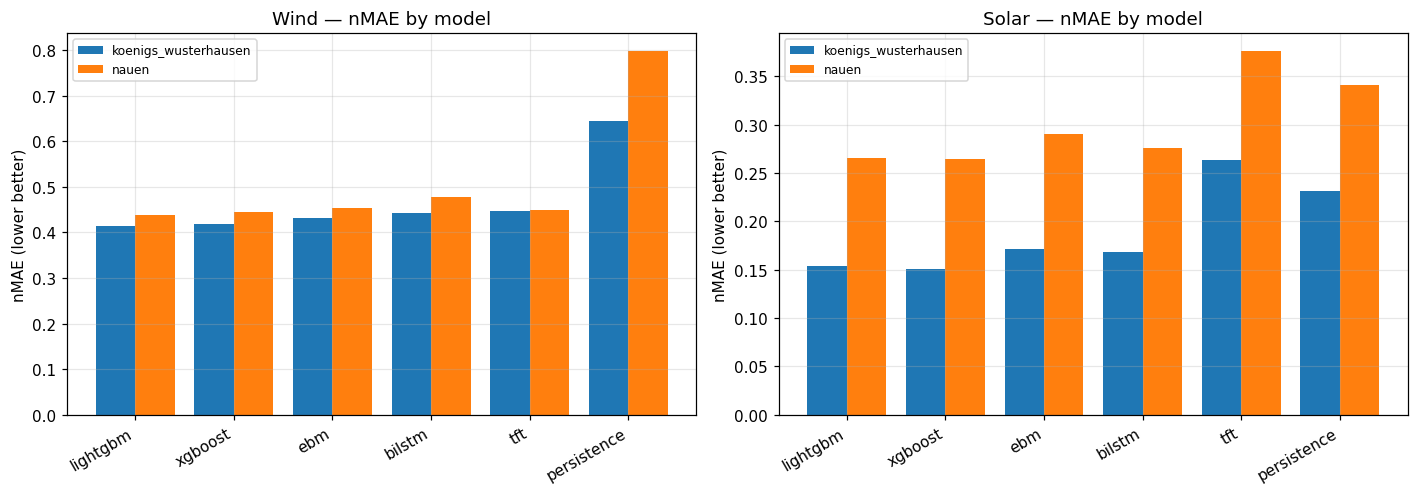

In [4]:
techs = ["wind", "solar"]
munis = sorted(metrics.municipality.unique())
model_order = ["lightgbm", "xgboost", "ebm", "bilstm", "tft", "persistence"]

fig, axes = plt.subplots(1, len(techs), figsize=(13, 4.6), sharey=False)
for ax, tech in zip(axes, techs):
    sub = metrics[metrics.technology == tech]
    models = [m for m in model_order if m in sub.model.unique()]
    x = np.arange(len(models)); w = 0.8 / len(munis)
    for i, muni in enumerate(munis):
        vals = [sub[(sub.model == mo) & (sub.municipality == muni)]["nmae"].mean() for mo in models]
        ax.bar(x + i * w - 0.4 + w / 2, vals, w, label=muni)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=30, ha="right")
    ax.set_title(f"{tech.capitalize()} — nMAE by model"); ax.set_ylabel("nMAE (lower better)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Best model per municipality × technology

The winning downscaling model and its skill vs the municipal persistence
baseline (`skill = 1 − nMAE_model / nMAE_persistence`; >0 means it beats
same-hour-yesterday).

In [5]:
pers = (metrics[metrics.model == "persistence"]
        .set_index(["municipality", "technology"])["nmae"].rename("nmae_persistence"))
best = (metrics[metrics.model != "persistence"]
        .sort_values("nmae").groupby(["municipality", "technology"]).head(1)
        .set_index(["municipality", "technology"]))
summary = best[["model", "nmae", "corr", "k"]].join(pers)
summary["skill_vs_persistence"] = 1 - summary["nmae"] / summary["nmae_persistence"]
summary = summary.reset_index().sort_values(["technology", "municipality"])
summary.style.format({"nmae": "{:.3f}", "corr": "{:.3f}", "k": "{:.4f}",
                      "nmae_persistence": "{:.3f}", "skill_vs_persistence": "{:.1%}"})

,municipality,technology,model,nmae,corr,k,nmae_persistence,skill_vs_persistence
0,koenigs_wusterhausen,solar,xgboost,0.150,0.976,0.0569,0.231,35.0%
1,nauen,solar,xgboost,0.264,0.906,0.1171,0.341,22.5%
2,koenigs_wusterhausen,wind,lightgbm,0.415,0.801,0.4851,0.646,35.7%
3,nauen,wind,lightgbm,0.437,0.834,0.0132,0.797,45.1%


## Predicted vs actual — best model, each municipality

Sanity check that the calibrated downscaling tracks real municipal generation over the held-out window.

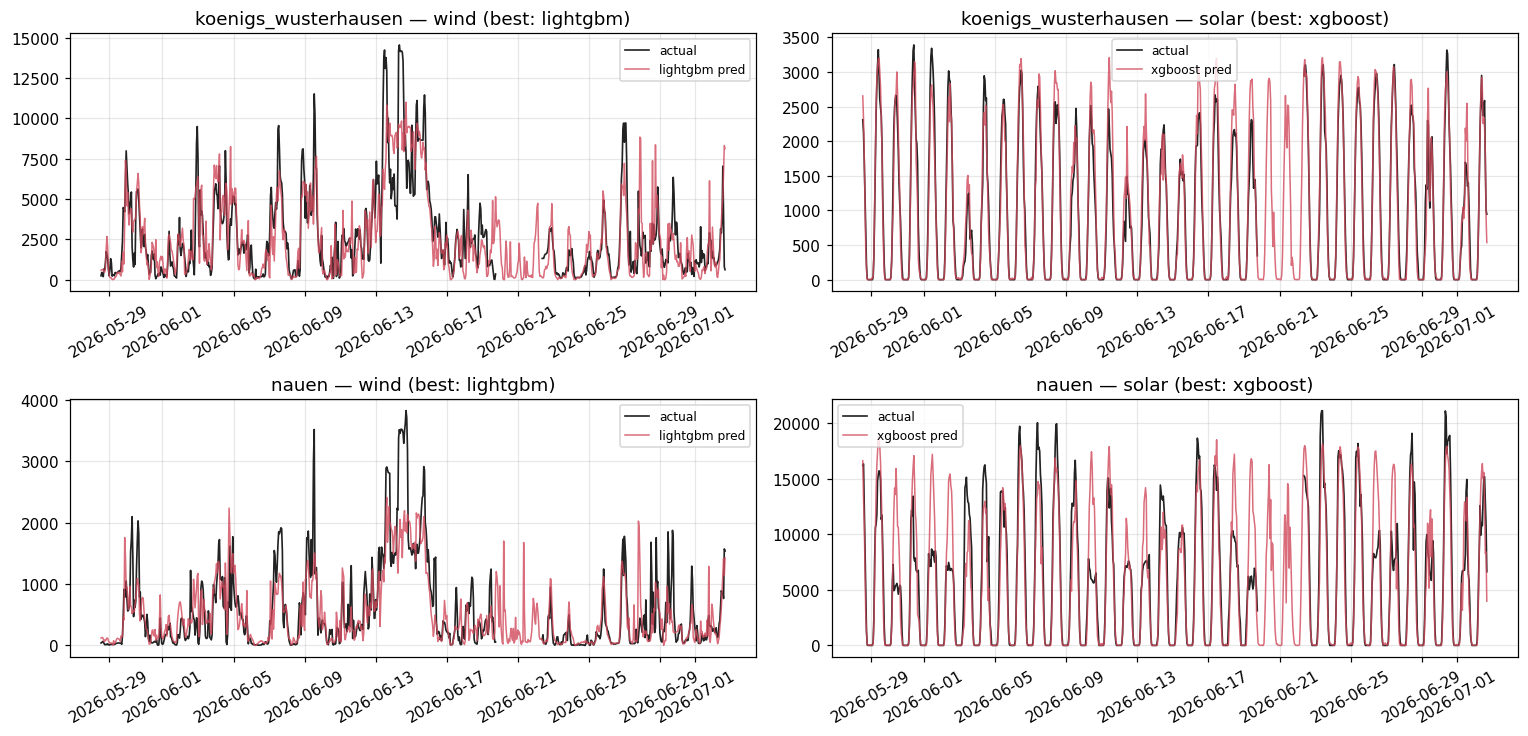

In [6]:
fig, axes = plt.subplots(len(munis), len(techs), figsize=(14, 3.4 * len(munis)), squeeze=False)
actual_col = {"wind": "windkraft", "solar": "photovoltaik"}
for r, slug in enumerate(munis):
    is_kw = slug == "koenigs_wusterhausen"
    p = f"{MUNIS[slug]['results_dir']}/{'kw_' if is_kw else ''}multi_model_validation.parquet"
    df = pd.read_parquet(p)
    for c, tech in enumerate(techs):
        ax = axes[r][c]
        bm = summary[(summary.municipality == slug) & (summary.technology == tech)]["model"].iloc[0]
        pred_col = f"pred_{bm}_{tech}"
        ax.plot(df.index, df[actual_col[tech]], lw=1.1, label="actual", color="#222")
        if pred_col in df:
            ax.plot(df.index, df[pred_col], lw=1.0, alpha=0.8, label=f"{bm} pred", color="#d1495b")
        ax.set_title(f"{slug} — {tech} (best: {bm})"); ax.legend(fontsize=8)
        ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Takeaways

- The downscaling contract now runs **unchanged across multiple municipalities** — adding a target is a config edit (`scraper.regions`), not a code change.
- **nMAE differs by locality and fleet mix**: KW's rooftop-heavy solar fleet and Nauen's wind-heavy fleet calibrate to very different `k`, yet the same macro CF model transfers to both.
- Tree models (LightGBM/XGBoost) lead; the deep models (BiLSTM/TFT) trail slightly at this short window. All learned models beat municipal persistence where `skill_vs_persistence > 0`.
- Numbers will firm up as the telemetry window grows toward a full year; rerun `municipal_validator` + `tft_municipal_validator` to refresh this report.